In [1]:
import argparse
import logging
from pathlib import Path
from time import time
import xarray as xr

from aislens.config import config
from aislens.dataprep import detrend_with_breakpoints_vectorized, detrend_with_breakpoints_ts
from aislens.utils import setup_logging

logger = logging.getLogger(__name__)

/Users/smurugan9/research/aislens/AISLENS/src/aislens/geospatial.py:1: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [4]:
ds = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/ENSEMBLES/ISMIP6/forcing-trends-ts/floatingBasalMassBalApplied_expAE05_Trend_2015-2300_ts.nc")

In [5]:
ds[config.MALI_FLOATINGBMB_VAR] = (ds[config.MALI_FLOATINGBMB_VAR].isel(Time=0) - ds[config.MALI_FLOATINGBMB_VAR])
    

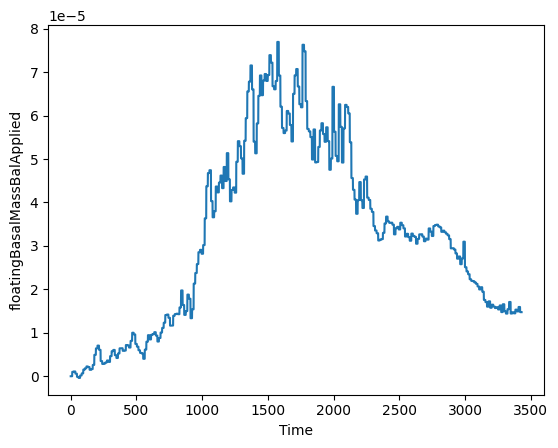

In [12]:
ds[config.MALI_FLOATINGBMB_VAR].plot()

In [ ]:
detrended_data = detrend_with_breakpoints_vectorized(ds[config.MALI_FLOATINGBMB_VAR], dim="Time", deg=1, model="rbf", penalty=10)

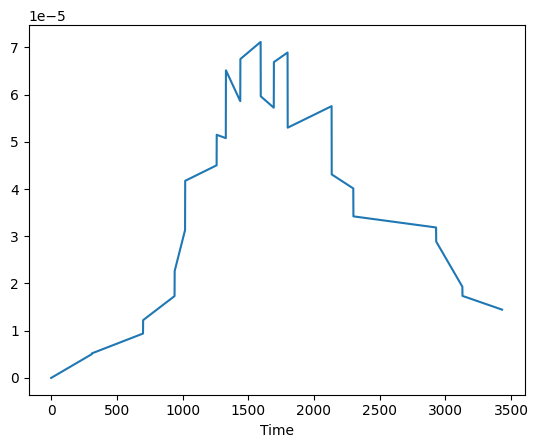

In [11]:
trend = ds[config.MALI_FLOATINGBMB_VAR] - detrended_data
trend.plot()

In [ ]:
def detrend_forcing(forcing_file_path, output_path, method='vectorized'):
    """Detrend forcing data using breakpoint detection."""
    logger.info(f"Loading {forcing_file_path}...")
    ds = xr.open_dataset(forcing_file_path)
    ds[config.MALI_FLOATINGBMB_VAR] = (ds[config.MALI_FLOATINGBMB_VAR].isel(Time=0) - 
                                        ds[config.MALI_FLOATINGBMB_VAR])
    
    if method == 'vectorized':
        logger.info("Detrending (vectorized - all spatial points)...")
        detrended_data = detrend_with_breakpoints_vectorized(
            ds[config.MALI_FLOATINGBMB_VAR], dim="Time", deg=1, model="rbf", penalty=10
        )
    else:
        logger.info("Detrending (time series - spatial mean)...")
        spatial_dims = [dim for dim in ds[config.MALI_FLOATINGBMB_VAR].dims if dim != 'Time']
        spatial_mean_ts = ds[config.MALI_FLOATINGBMB_VAR].mean(dim=spatial_dims)
        detrended_data = detrend_with_breakpoints_ts(
            spatial_mean_ts, dim="Time", deg=1, model="rbf", penalty=10
        )
    
    trend = (ds - detrended_data.to_dataset(name=config.MALI_FLOATINGBMB_VAR))
    trend = trend.rename({config.MALI_FLOATINGBMB_VAR: config.AISLENS_FLOATINGBMB_VAR})
    
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    trend.to_netcdf(output_path)
    logger.info(f"Trend saved as {output_path}")


## TREND EXTRACTION FROM MALI ISMIP6 OUTPUTS

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
from aislens.config import config

In [2]:
config.FILE_ISMIP6_SSP126_FORCING

PosixPath('/Users/smurugan9/research/aislens/AISLENS/data/MALI/ISMIP6/SSP126/output/extracted_vars/extracted_flux_expAE10_2015-2300.nc')

In [7]:
#ds126_flux = xr.open_dataset(config.FILE_ISMIP6_SSP126_FORCING, chunks={'Time': 10})
#ds126_state = xr.open_dataset(config.FILE_ISMIP6_SSP585_FORCING, chunks={'Time': 10})

ds585_flux = xr.open_dataset(config.FILE_ISMIP6_SSP585_FORCING, chunks={'Time': 10})
#ds585_state = xr.open_dataset(config.FILE_ISMIP6_SSP585_FORCING, chunks={'Time': 10})

In [8]:
# Adjust the sign on floatingBMB
#ds126_flux[config.MALI_FLOATINGBMB_VAR] = (ds126_flux[config.MALI_FLOATINGBMB_VAR].isel(Time=0) - ds126_flux[config.MALI_FLOATINGBMB_VAR])
ds585_flux[config.MALI_FLOATINGBMB_VAR] = (ds585_flux[config.MALI_FLOATINGBMB_VAR].isel(Time=0) - ds585_flux[config.MALI_FLOATINGBMB_VAR])

In [9]:
# Read the iceshelves region mask for MALI grid using geopandas
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
#shelves_gdf = gpd.read_file("/Users/smurugan9/research/aislens/AISLENS/data/external/aislens_draftDepen_regionMasks.nc")

In [3]:
iceshelf_masks = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/external/aislens_draftDepen_regionMasks.nc")
iceshelf_masks

<xarray.Dataset>
Dimensions:          (nCells: 385379, nRegions: 133)
Dimensions without coordinates: nCells, nRegions
Data variables:
    regionCellMasks  (nCells, nRegions) int32 ...
    regionNames      (nRegions) |S19 ...
    history          (nRegions) object ...
    constituents     (nRegions) object ...
Attributes:
    history:  Wed Dec 10 11:32:43 2025: /Users/smurugan9/opt/anaconda3/envs/a...

In [11]:
iceshelf_masks.regionNames.values[104]

b'Western_Ross'

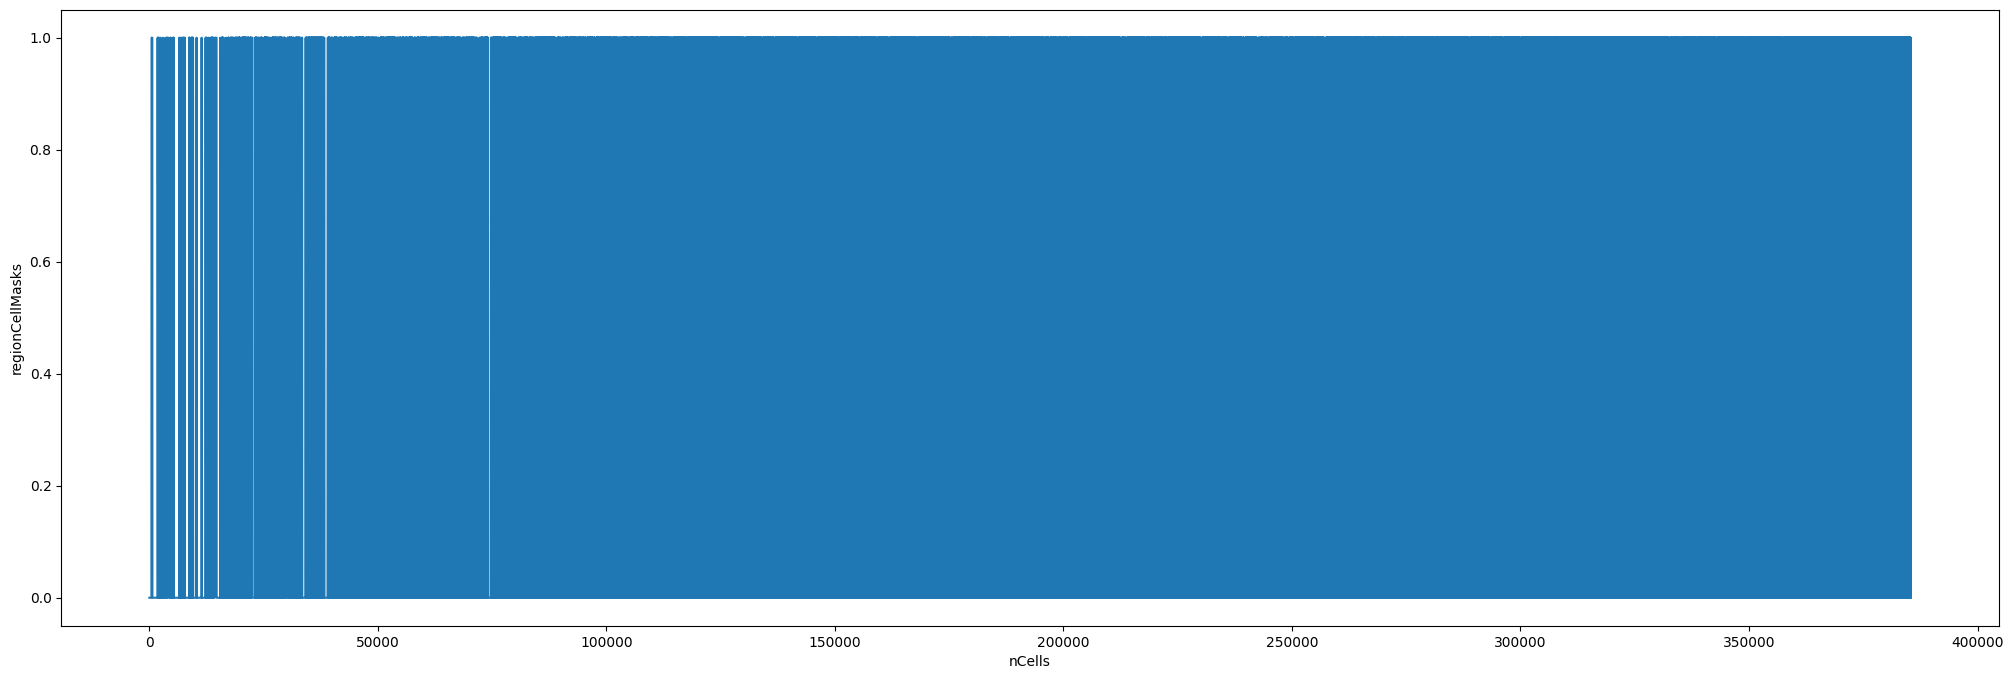

In [12]:
plt.figure(figsize=(25,8))
i = 104
iceshelf_masks.regionCellMasks.isel(nRegions=i)[:].plot()

In [11]:
# Calculate mean flux variable along nCells, i.e., time series
#ds126_fluxts = ds126_flux[config.MALI_FLOATINGBMB_VAR].mean(dim='nCells')
ds585_fluxts = ds585_flux[config.MALI_FLOATINGBMB_VAR].mean(dim='nCells')

Text(0, 0.5, 'Floating Basal Mass Balance (kg/m/s2)')

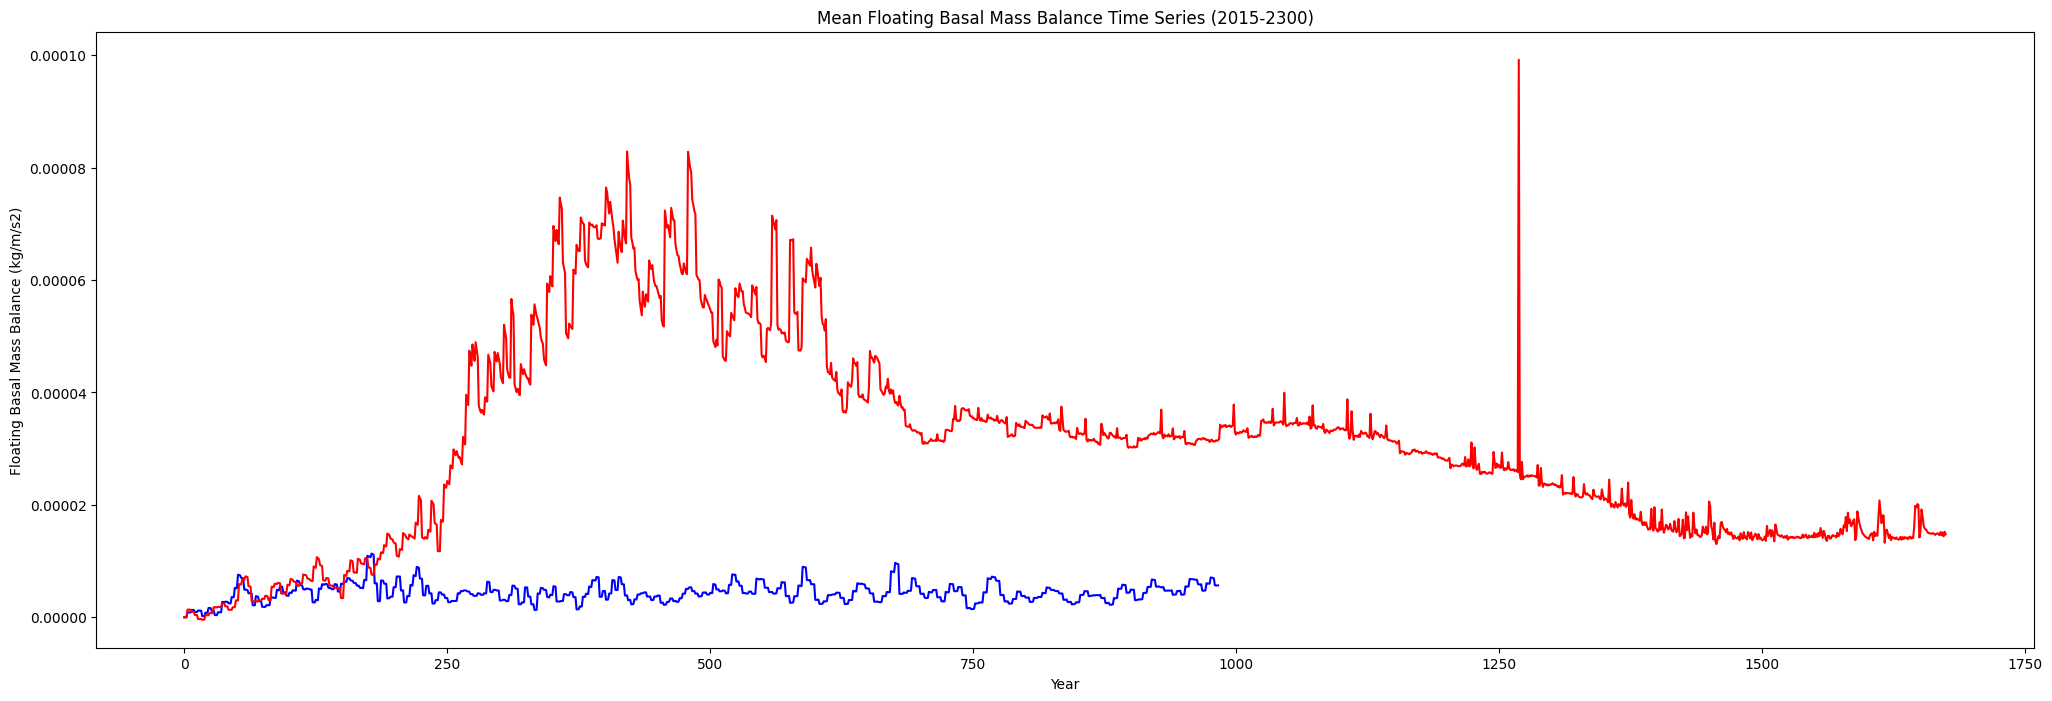

In [ ]:
plt.figure(figsize=(25,8))
ds126_fluxts.plot(label='expAE10 (SSP1 2.6)', color='blue')
ds585_fluxts.plot(label='expAE05 (SSP5 8.5)', color='red')
plt.title('Mean Floating Basal Mass Balance Time Series (2015-2300)')
plt.xlabel('Year')
plt.ylabel('Floating Basal Mass Balance (kg/m/s2)')

In [17]:
# Recompute and plot mean flux time series using netCDF4.Dataset and daysSinceStart/deltat
# Use calendar years with start year = 2015 (convert years-since-start -> calendar year)
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from aislens.config import config

# Paths (match the files previously opened with xarray earlier in this notebook)
path126 = config.FILE_ISMIP6_SSP126_FORCING
path585 = config.FILE_ISMIP6_SSP585_FORCING

# Open with netCDF4 (do not modify your xarray objects)
#f126 = Dataset(path126, 'r')
f585 = Dataset(path585, 'r')

# Compute years from daysSinceStart (consistent with plot_ensemble* scripts)
#days126 = f126.variables['daysSinceStart'][:]
#years126 = days126 / 365.0
#years126 = years126 - years126[0]
# Convert to calendar years (start year = 2015)
#cal_years126 = years126 + 2015.0

days585 = f585.variables['daysSinceStart'][:]
years585 = days585 / 365.0
years585 = years585 - years585[0]
cal_years585 = years585 + 2015.0

# Variable name used in this repo
varname = config.MALI_FLOATINGBMB_VAR

# Read variable arrays and compute spatial mean across nCells
# Apply the same sign adjustment you used with xarray: initial - full
#val126 = f126.variables[varname][0] - f126.variables[varname][:]
val585 = f585.variables[varname][0] - f585.variables[varname][:]

# Defensive handling if dimensions are (nCells, Time)
# After the subtraction we expect shape (Time, nCells) but check and transpose if necessary.
#try:
#    nCells126 = len(f126.dimensions.get('nCells', []))
#except Exception:
#    nCells126 = None
#try:
nCells585 = len(f585.dimensions.get('nCells', []))
#except Exception:
#    nCells585 = None

#if nCells126 and val126.shape[0] == nCells126:
#    val126 = val126.T
if nCells585 and val585.shape[0] == nCells585:
    val585 = val585.T

# Compute mean over spatial axis (nCells) -> result shape (Time,)
#mean126 = np.nanmean(val126, axis=1)
mean585 = np.nanmean(val585, axis=1)

# Close files
#f126.close()
f585.close()

# Plot using calendar years
plt.figure(figsize=(12,5))
#plt.plot(cal_years126, mean126, label='expAE10 (SSP1 2.6) - Dataset', color='blue')
plt.plot(cal_years126, ds_dedraftts, label='expAE10 (SSP 1 2.6) - Dedrafted')
plt.plot(cal_years585, mean585, label='expAE05 (SSP5 8.5) - Dataset', color='red')
plt.title('Mean Floating Basal Mass Balance Time Series (2015-2300)')
plt.xlabel('Year (calendar)')
plt.ylabel('Floating Basal Mass Balance (kg/m/s^2)')
plt.xlim(2015, 2300)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'cal_years126' is not defined

<Figure size 1200x500 with 0 Axes>

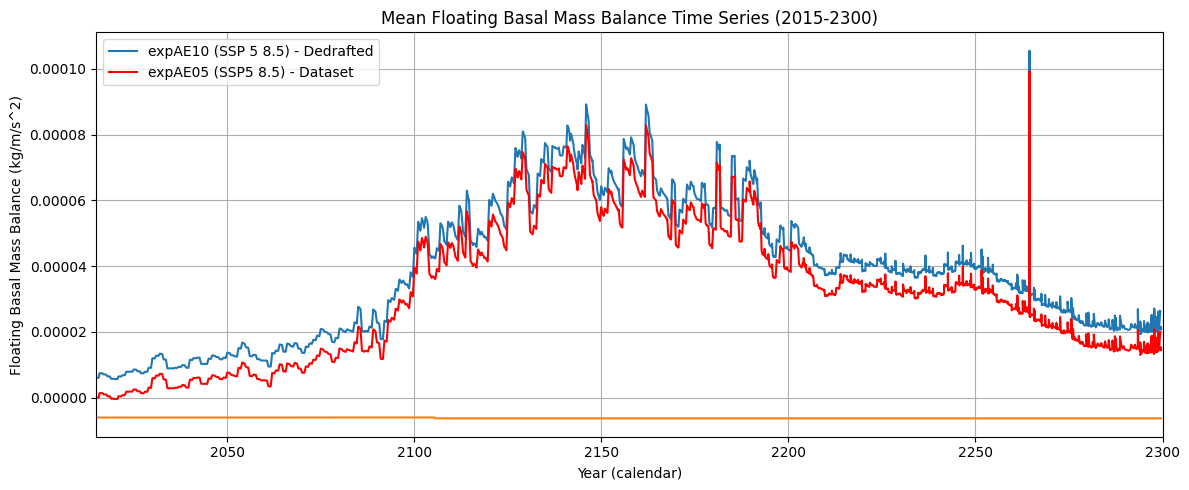

In [19]:
# Plot using calendar years
plt.figure(figsize=(12,5))
#plt.plot(cal_years585, mean126, label='expAE10 (SSP1 2.6) - Dataset', color='blue')
plt.plot(cal_years585, ds_dedraftts, label='expAE10 (SSP 5 8.5) - Dedrafted')
plt.plot(cal_years585, mean585, label='expAE05 (SSP5 8.5) - Dataset', color='red')
plt.plot(cal_years585, mean585 - ds_dedraftts)
#plt.plot(cal_years585, - ds_dedraftts -mean585)
plt.title('Mean Floating Basal Mass Balance Time Series (2015-2300)')
plt.xlabel('Year (calendar)')
plt.ylabel('Floating Basal Mass Balance (kg/m/s^2)')
plt.xlim(2015, 2300)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Clip datasets using `iceshelf_masks.regionCellMasks` for a sample region (nRegion)
# This operates on the xarray objects `ds126_flux`, `ds126_state`, `ds585_flux`, `ds585_state`
# and produces masked copies named `*_masked`. Masked-out cells are set to NaN.
import numpy as np

nRegion = 100
print(f"Applying mask for nRegion={nRegion}")

# Extract mask (DataArray along nCells)
mask = iceshelf_masks.regionCellMasks.isel(nRegions=nRegion)
# Ensure mask is 0/1 integers
mask = mask.astype('int')
print('Mask retained cells:', int(mask.sum().item()))

# Helper to apply mask to all data variables that include the 'nCells' dimension
# Use NaN for masked-out values so reductions ignore them naturally.
def apply_mask_to_ds(ds, mask_da):
    ds_masked = ds.copy(deep=True)
    for var in list(ds_masked.data_vars):
        da = ds_masked[var]
        if 'nCells' in da.dims:
            # where mask==1 keep values, otherwise set to NaN
            ds_masked[var] = da.where(mask_da == 1, other=np.nan)
    return ds_masked

# Create masked datasets (sample for this one region)
ds126_flux_masked = apply_mask_to_ds(ds126_flux, mask)
ds126_state_masked = apply_mask_to_ds(ds126_state, mask)
ds585_flux_masked = apply_mask_to_ds(ds585_flux, mask)
ds585_state_masked = apply_mask_to_ds(ds585_state, mask)

# Inspect and show a small summary for the ds585_flux masked result
var = config.MALI_FLOATINGBMB_VAR
print('\nSample summary for ds585_flux_masked:')
# Number of retained cells (based on mask)
print('Retained cell count (mask):', int(mask.sum().item()))

# Show masked spatial mean for first 5 timesteps (NaNs ignored by mean)
mean_ts = ds585_flux_masked[var].mean(dim='nCells')
print('Mean (first 5 timesteps) for masked ds585_flux:', np.array(mean_ts.values[:5]))


Applying mask for nRegion=100
Mask retained cells: 2358

Sample summary for ds585_flux_masked:
Retained cell count (ds585): 0
First retained cell indices (up to 20): []

Sample summary for ds585_flux_masked:
Retained cell count (ds585): 0
First retained cell indices (up to 20): []


Mean (first 5 timesteps) for masked ds585_flux: [ 0.00000000e+00 -1.50574791e-10 -5.58031948e-11  2.68199011e-08
  2.67688074e-08]


Plotting 780 points for nRegion=100 (time-mean per cell; lowerSurface <= 0)


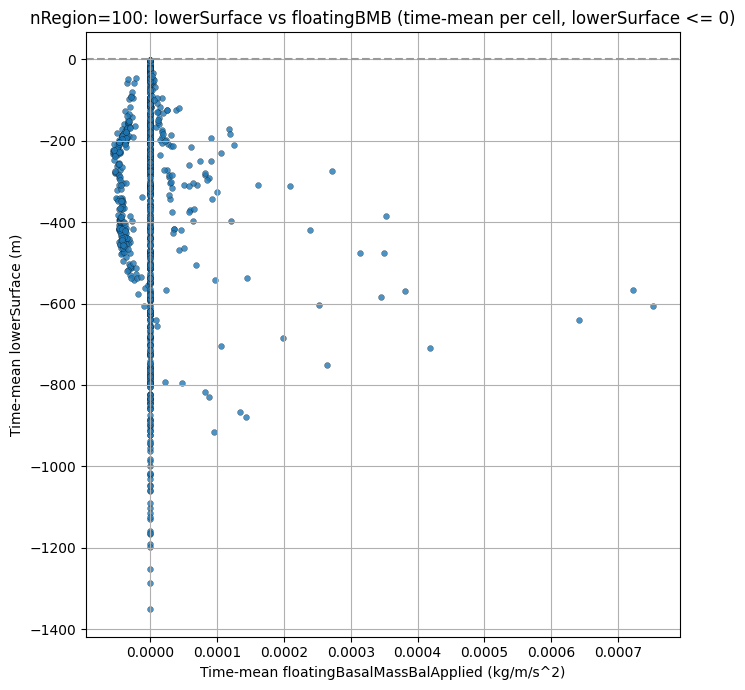

In [36]:
# Scatter plot of TIME-MEAN values (per-cell) for masked region (nRegion) — x: floatingBMB, y: lowerSurface
# Additionally mask out cells where lowerSurface > 0 (keep only lowerSurface <= 0)
import numpy as np
import matplotlib.pyplot as plt

flux_var = config.MALI_FLOATINGBMB_VAR
state_var = 'lowerSurface'

# Compute time-mean across the Time dimension (result indexed by nCells)
flux_time_mean = ds585_flux_masked[flux_var].mean(dim='Time')
lower_time_mean = ds585_state_masked[state_var].mean(dim='Time')

# Convert to numpy arrays (indexed by nCells)
flux_vals = np.asarray(flux_time_mean.values).ravel()
lower_vals = np.asarray(lower_time_mean.values).ravel()

# Recreate mask for this nRegion (ensure consistent with masked datasets)
mask_vals = iceshelf_masks.regionCellMasks.isel(nRegions=nRegion).astype('int').values

# Select only retained cells (mask == 1)
retained_idx = np.nonzero(mask_vals)[0]
if retained_idx.size == 0:
    raise RuntimeError(f"No retained cells found for nRegion={nRegion}")

x = flux_vals[retained_idx]
y = lower_vals[retained_idx]

# Mask out cells where lowerSurface > 0
keep_mask = (y <= 0)

# Also filter finite values
valid = np.isfinite(x) & np.isfinite(y) & keep_mask
x = x[valid]
y = y[valid]

print(f"Plotting {x.size} points for nRegion={nRegion} (time-mean per cell; lowerSurface <= 0)")

plt.figure(figsize=(7,7))
plt.scatter(x, y, s=18, alpha=0.8, edgecolor='k', linewidth=0.2)
plt.xlabel('Time-mean floatingBasalMassBalApplied (kg/m/s^2)')
plt.ylabel('Time-mean lowerSurface (m)')
plt.title(f'nRegion={nRegion}: lowerSurface vs floatingBMB (time-mean per cell, lowerSurface <= 0)')
plt.grid(True)
plt.axhline(0, color='0.6', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
import xarray as xr
from aislens.config import config
dsf = xr.open_dataset('/Users/smurugan9/research/aislens/AISLENS/data/MALI/ISMIP6/SSP126/output/floatingBMB/floatingBasalMassBalApplied_expAE10-SSP126_Trend_2015-2300.nc')
dss = xr.open_dataset('/Users/smurugan9/research/aislens/AISLENS/data/MALI/ISMIP6/SSP126/output/floatingBMB/state_expAE10-SSP126_Trend_2015-2300.nc')
print('flux Time len:', dsf[config.TIME_DIM].size)
print('state Time len:', dss[config.TIME_DIM].size)
print('flux Time sample:', dsf[config.TIME_DIM].values[:5])
print('state Time sample:', dss[config.TIME_DIM].values[:5])

flux Time len: 984
state Time len: 285
flux Time sample: [0 1 2 3 4]
state Time sample: [0 1 2 3 4]


In [2]:
import xarray as xr
from aislens.config import config
dsf = xr.open_dataset('/Users/smurugan9/research/aislens/AISLENS/data/MALI/ISMIP6/SSP126/output/floatingBMB/floatingBasalMassBalApplied_expAE10-SSP126_Trend_2015-2300.nc')
dss = xr.open_dataset('/Users/smurugan9/research/aislens/AISLENS/data/MALI/ISMIP6/SSP126/output/floatingBMB/state_expAE10-SSP126_Trend_2015-2300.nc')
print('flux Time len:', dsf[config.TIME_DIM].size if config.TIME_DIM in dsf.coords else 'no Time')
print('state Time len:', dss[config.TIME_DIM].size if config.TIME_DIM in dss.coords else 'no Time')
print('flux daysSinceStart present:', 'daysSinceStart' in dsf)
print('state daysSinceStart present:', 'daysSinceStart' in dss)
if 'daysSinceStart' in dsf:
    print('flux daysSinceStart sample:', dsf['daysSinceStart'].values[:5])
if 'daysSinceStart' in dss:
    print('state daysSinceStart sample:', dss['daysSinceStart'].values[:5])

flux Time len: no Time
state Time len: no Time
flux daysSinceStart present: True
state daysSinceStart present: True
flux daysSinceStart sample: [484722297999964800 494836453999987200 504576000000000000
 511910321999990400 523661149000022400]
state daysSinceStart sample: [504576000000000000 536112000000000000 567648000000000000
 599184000000000000 630720000000000000]


In [14]:
ds_dedraft = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/forcing-trend-scenarios_test/dedrafted_extracted_flux_expAE05_2015-2300.nc")

In [15]:
ds_dedraftts = ds_dedraft['floatingBasalMassBalApplied'].mean(dim='nCells')

In [31]:
ds_testtrend = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/ISMIP6/SSP585/output/extracted_vars/extracted_flux_expAE05_2015-2300_with_state.nc")

In [26]:
ds_testtrend.Time.values

array([   0,    1,    2, ..., 1673, 1674, 1675])

In [36]:
ds_testtrend_mean = ds_testtrend.mean("Time")

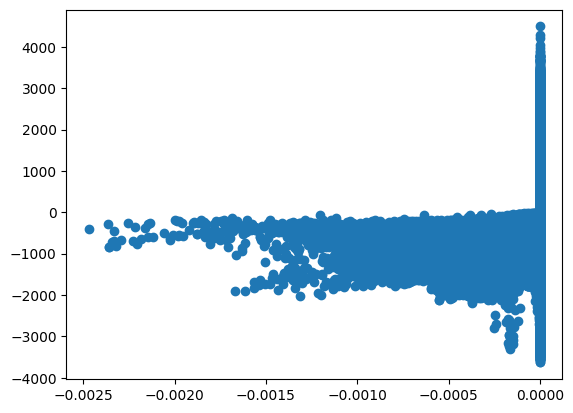

In [37]:
plt.scatter(ds_testtrend_mean.floatingBasalMassBalApplied, ds_testtrend_mean.lowerSurface)

In [35]:
ds_testtrend_mean.lowerSurface

<xarray.DataArray 'lowerSurface' (Time: 1676)>
array([-227.40110738, -227.3275279 , -227.25678043, ..., -296.24021683,
       -296.24324575, -296.24833297])
Coordinates:
  * Time     (Time) float64 5.61e+03 5.727e+03 5.84e+03 ... -1.04e+05 -1.04e+05

In [1]:
import xarray as xr
from aislens.config import config

In [2]:
ds_dedrafted_126 = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/processed/dedrafted-ssp-forcings/dedrafted_extracted_flux_expAE10_2015-2300_with_state_ts.nc")
ds_dedrafted_585 = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/processed/dedrafted-ssp-forcings/dedrafted_extracted_flux_expAE05_2015-2300_with_state_ts.nc")

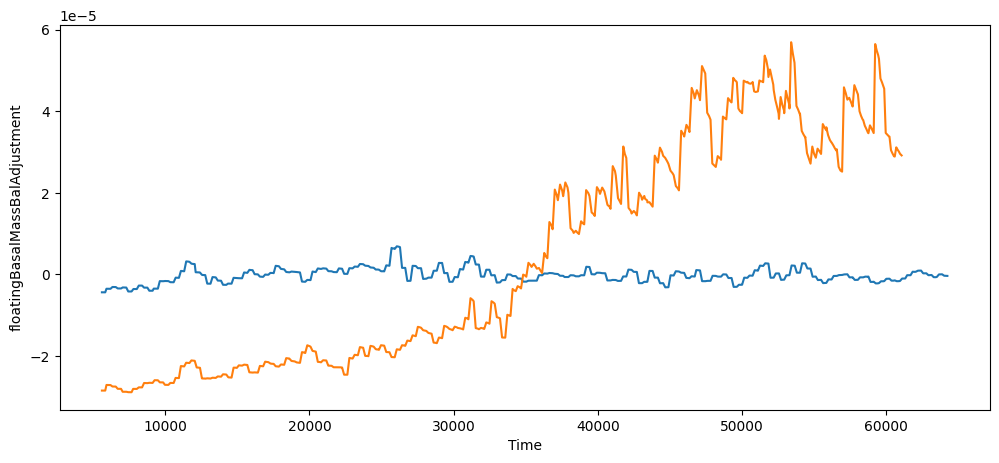

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
ds_dedrafted_126['floatingBasalMassBalAdjustment'][:500].plot()
ds_dedrafted_585['floatingBasalMassBalAdjustment'][:500].plot()


In [6]:
ds_dedrafted_126

<xarray.Dataset>
Dimensions:                         (Time: 984)
Coordinates:
  * Time                            (Time) float64 5.61e+03 ... -1.04e+05
    daysSinceStart                  (Time) timedelta64[ns] ...
    deltat                          (Time) float64 ...
Data variables:
    floatingBasalMassBalAdjustment  (Time) float64 ...
Attributes:
    history:  Thu Dec 11 01:17:58 2025: ncwa -a nCells dedrafted_extracted_fl...
    NCO:      netCDF Operators version 5.1.0 (Homepage = http://nco.sf.net, C...

# PLOTS OF EXTRACTED TREND

In [22]:
import xarray as xr
import matplotlib.pyplot as plt
DATA_DIR = "/Users/smurugan9/research/aislens/AISLENS/data/processed/forcing-trend-scenarios_test/"
ds_trend_exp05 = xr.open_dataset(DATA_DIR + "trend_dedrafted_extracted_flux_expAE05_2015-2300_with_state_ts.nc")
ds_trend_exp10 = xr.open_dataset(DATA_DIR + "trend_dedrafted_extracted_flux_expAE10_2015-2300_with_state_ts.nc")


ds_dedrafted_exp05 = xr.open_dataset(DATA_DIR + "dedrafted_extracted_flux_expAE05_2015-2300_with_state_ts.nc")
ds_dedrafted_exp10 = xr.open_dataset(DATA_DIR + "dedrafted_extracted_flux_expAE10_2015-2300_with_state_ts.nc")

In [23]:
DATA_DIRfinal = "/Users/smurugan9/research/aislens/AISLENS/data/processed/deterministic-trend-forcings/"

In [24]:
ds_forcing_adj_trend_ssp585 = xr.open_dataset(DATA_DIRfinal + "AIS_4to20km_r01_20220907_AISLENS-Forcing_Trend_SSP585_ts.nc")
ds_forcing_adj_trend_ssp126 = xr.open_dataset(DATA_DIRfinal + "AIS_4to20km_r01_20220907_AISLENS-Forcing_Trend_SSP126_ts.nc")

In [27]:
ds_forcing_adj_trend_ssp126

<xarray.Dataset>
Dimensions:                         (Time: 3600)
Dimensions without coordinates: Time
Data variables:
    floatingBasalMassBalAdjustment  (Time) float64 ...
    xtime                           (Time) |S64 ...
Attributes:
    on_a_sphere:                NO
    sphere_radius:              0.0
    is_periodic:                NO
    parent_id:                  lclrmiizwz\npmtzb5h15d\nsjrc424ult\nt28yfwmmt...
    mesh_spec:                  1.0
    Conventions:                MPAS
    source:                     MpasMeshConverter.x
    file_id:                    y808v7bkix
    history:                    Fri Dec 12 19:47:10 2025: ncwa -a nCells /sto...
    NCO:                        netCDF Operators version 5.1.0 (Homepage = ht...
    history_of_appended_files:  Fri Dec 12 19:00:39 2025: Appended file /stor...

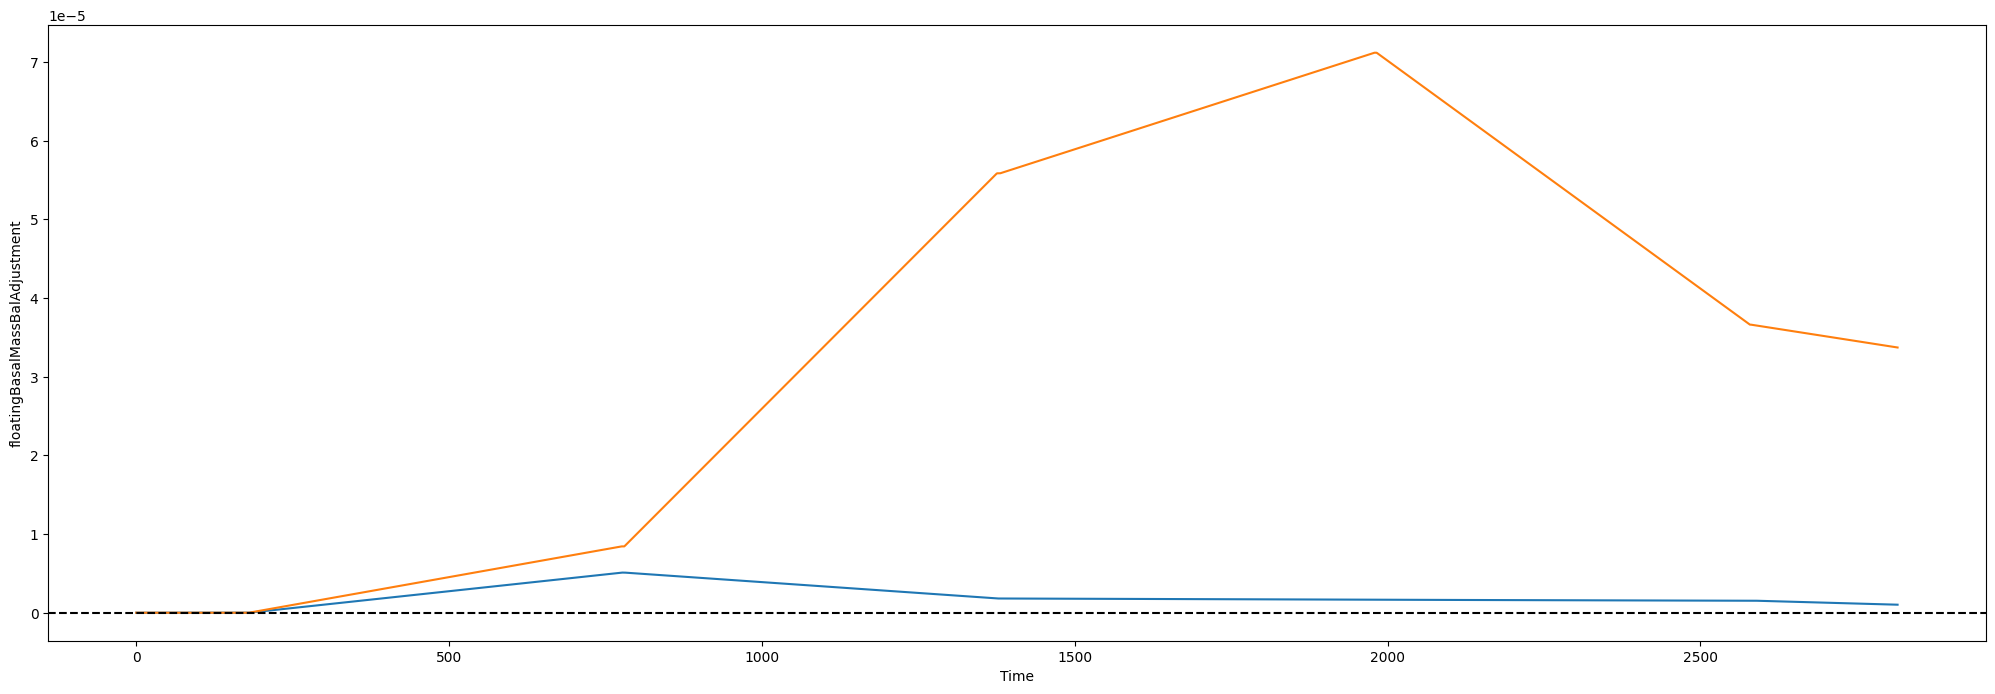

In [25]:
plt.figure(figsize=(25,8))
ds_forcing_adj_trend_ssp126['floatingBasalMassBalAdjustment'].plot()
ds_forcing_adj_trend_ssp585['floatingBasalMassBalAdjustment'].plot()
plt.axhline(0, color='black', linestyle='--')

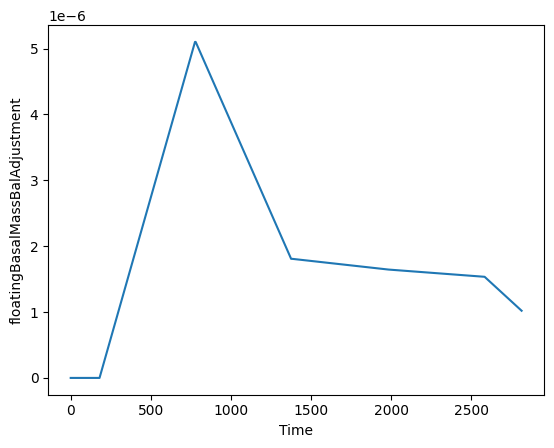

In [28]:
ds_forcing_adj_trend_ssp126['floatingBasalMassBalAdjustment'].plot()
#ds_forcing_adj_trend_ssp126['floatingBasalMassBalAdjustment_var'].plot()
#(ds_forcing_adj_trend_ssp126['floatingBasalMassBalAdjustment_var'] - ds_forcing_adj_trend_ssp126['floatingBasalMassBalAdjustment']).plot()


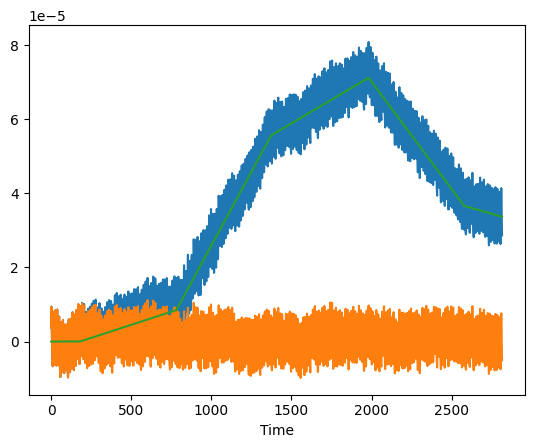

In [17]:
ds_forcing_adj_trend_ssp585['floatingBasalMassBalAdjustment'].plot()
ds_forcing_adj_trend_ssp585['floatingBasalMassBalAdjustment_var'].plot()
(ds_forcing_adj_trend_ssp585['floatingBasalMassBalAdjustment'] - ds_forcing_adj_trend_ssp585['floatingBasalMassBalAdjustment_var']).plot()


<Figure size 2500x800 with 0 Axes>

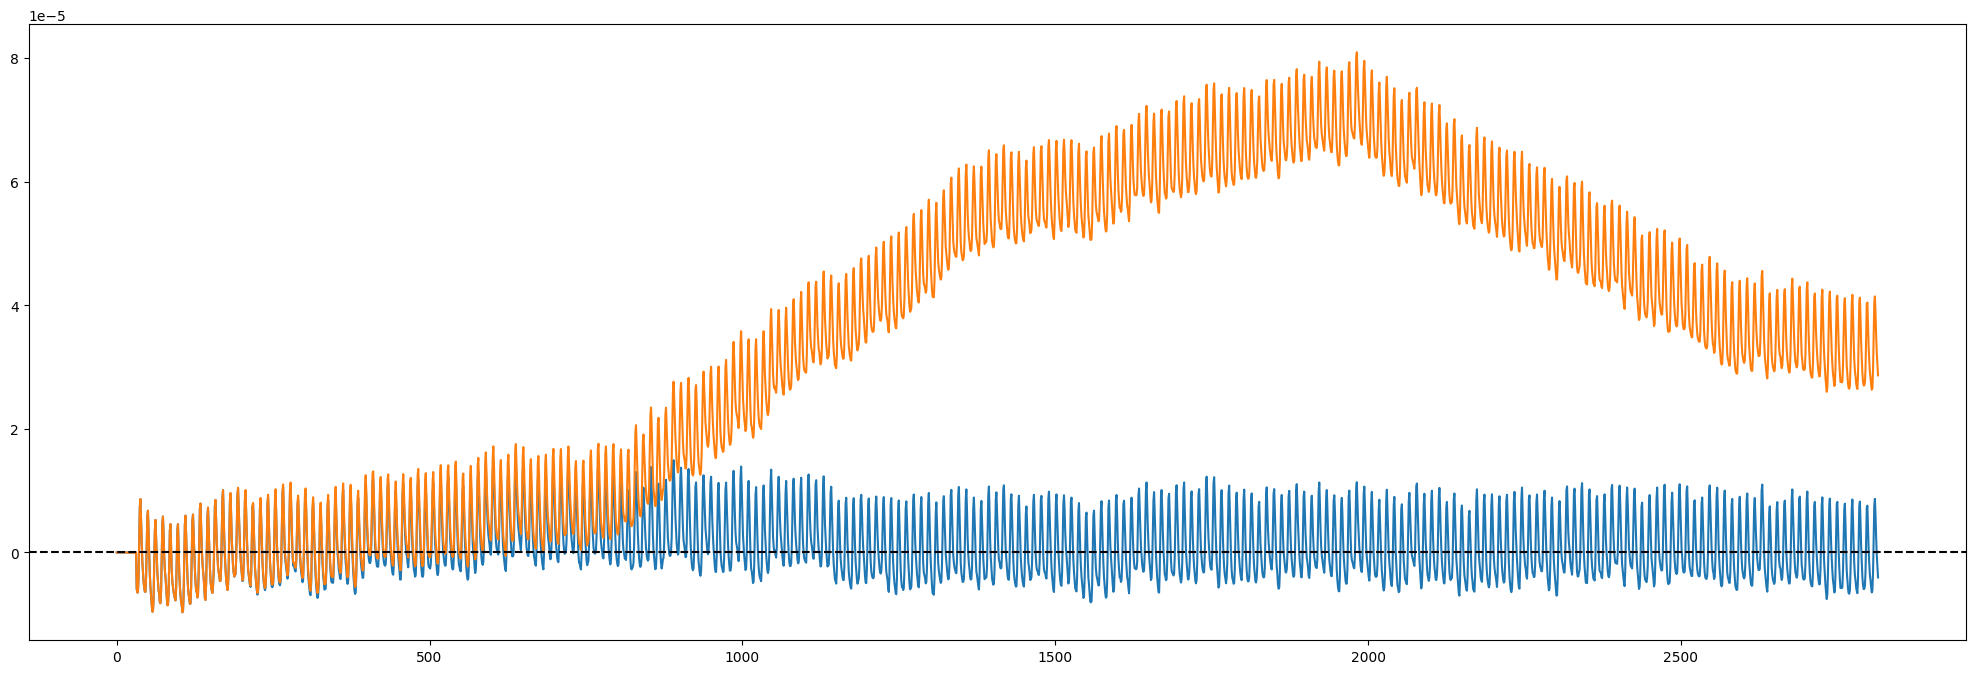

In [4]:
plt.figure(figsize=(25,8))

#plt.plot(ds_dedrafted_exp05['floatingBasalMassBalAdjustment'] - ds_dedrafted_exp05['floatingBasalMassBalAdjustment'][0])
#plt.plot(ds_dedrafted_exp10['floatingBasalMassBalAdjustment'] - ds_dedrafted_exp10['floatingBasalMassBalAdjustment'][0])
#plt.plot(ds_trend_exp05['floatingBasalMassBalAdjustment'])
#plt.plot(ds_trend_exp10['floatingBasalMassBalAdjustment'])
# plot horizontal 0 line

# plot same trend lines but with the initial time step subtracted
plt.figure(figsize=(25,8))
#plt.plot(ds_dedrafted_exp05['floatingBasalMassBalAdjustment'] - ds_dedrafted_exp05['floatingBasalMassBalAdjustment'][0])
#plt.plot(ds_dedrafted_exp10['floatingBasalMassBalAdjustment'] - ds_dedrafted_exp10['floatingBasalMassBalAdjustment'][0])
#plt.plot(ds_trend_exp05['floatingBasalMassBalAdjustment'] - ds_trend_exp05['floatingBasalMassBalAdjustment'][0])
#plt.plot(ds_trend_exp10['floatingBasalMassBalAdjustment'] - ds_trend_exp10['floatingBasalMassBalAdjustment'][0])
plt.plot(ds_forcing_adj_trend_ssp585['floatingBasalMassBalAdjustment'])
plt.plot(ds_forcing_adj_trend_ssp126['floatingBasalMassBalAdjustment'])
plt.axhline(0, color='black', linestyle='--')


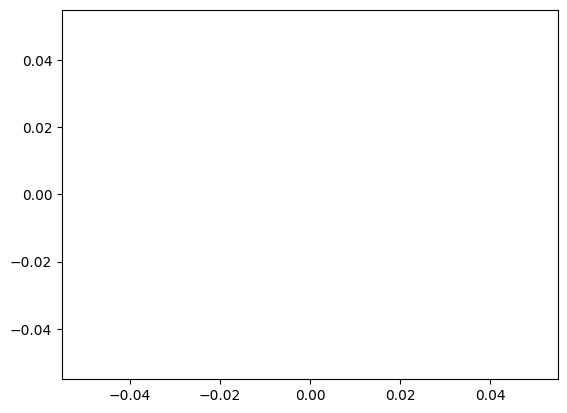

In [5]:
plt.plot(ds_trend_exp05['floatingBasalMassBalAdjustment'])
plt.plot(ds_trend_exp10['floatingBasalMassBalAdjustment'])

# CHECK TREND FILE REGIONALLY

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
iceshelf_masks = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/external/aislens_draftDepen_regionMasks.nc")
iceshelf_masks

trend_ssp1 = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/processed/deterministic-trend-forcings/AIS_4to20km_r01_20220907_AISLENS-Forcing_Trend_SSP126.nc", chunks={'Time': 120})
trend_ssp5 = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/processed/deterministic-trend-forcings/AIS_4to20km_r01_20220907_AISLENS-Forcing_Trend_SSP585.nc", chunks={'Time': 120})

In [7]:
trend_ssp1

<xarray.Dataset>
Dimensions:                         (Time: 3600, nCells: 385379)
Dimensions without coordinates: Time, nCells
Data variables:
    floatingBasalMassBalAdjustment  (Time, nCells) float64 dask.array<chunksize=(120, 385379), meta=np.ndarray>
    xtime                           (Time) |S64 dask.array<chunksize=(120,), meta=np.ndarray>
Attributes:
    on_a_sphere:                NO
    sphere_radius:              0.0
    is_periodic:                NO
    parent_id:                  lclrmiizwz\npmtzb5h15d\nsjrc424ult\nt28yfwmmt...
    mesh_spec:                  1.0
    Conventions:                MPAS
    source:                     MpasMeshConverter.x
    file_id:                    y808v7bkix
    history:                    Fri Dec 12 19:43:27 2025: ncks -O -x -v float...
    NCO:                        netCDF Operators version 5.1.0 (Homepage = ht...
    history_of_appended_files:  Fri Dec 12 19:00:39 2025: Appended file /stor...

In [16]:
mask = iceshelf_masks.regionCellMasks.isel(nRegions=113).astype('int')
trend_masked = trend_ssp5.where(mask == 1, other=np.nan)

In [19]:
trend_ts = trend_masked.floatingBasalMassBalAdjustment.sum(dim='nCells').compute()


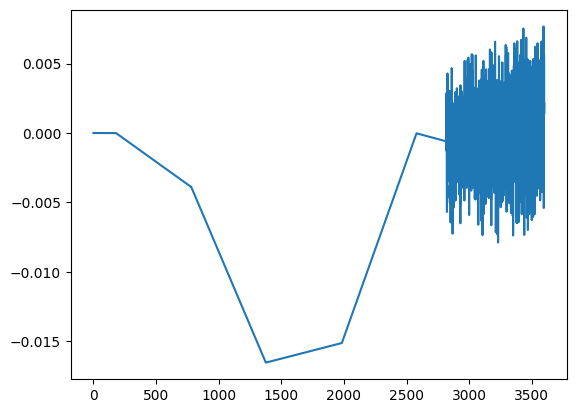

In [21]:
plt.plot(-trend_ts)

In [8]:
# Plot floatingBasalMassBalAdjustment for both SSP126 and SSP585 trends filtered by masks provided by iceshelf_masks.regionCellMasks

def plot_trend_by_region(trend_ds, nRegion):
    mask = iceshelf_masks.regionCellMasks.isel(nRegions=nRegion).astype('int')
    trend_masked = trend_ds.where(mask == 1, other=np.nan)
    trend_masked_ts = trend_masked['floatingBasalMassBalAdjustment'].mean(dim='nCells')
    plt.plot(trend_masked_ts['floatingBasalMassBalAdjustment'])
    plt.title(f'nRegion={nRegion}: floatingBasalMassBalAdjustment (time-mean per cell, lowerSurface <= 0)')
    plt.xlabel('Year (calendar)')
    plt.ylabel('Floating Basal Mass Balance Adjustment (kg/m/s^2)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage
plot_trend_by_region(trend_ssp1, 104)

KeyError: 'floatingBasalMassBalAdjustment'

## TEST TREND+VAR FILES

In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from aislens.config import config

In [31]:
det585 = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/processed/deterministic-trend-forcings/AIS_4to20km_r01_20220907_AISLENS-Forcing_Trend_SSP585_negAdj.nc", chunks={'Time': 120})
em585 = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/processed/vargen_realizations-ssn-trend-ssp585/AIS_4to20km_r01_20220907_AISLENS-Forcing_1.nc", chunks={'Time': 120})

In [33]:
det585_ts = det585.floatingBasalMassBalAdjustment.mean(dim='nCells')
em585_ts = em585.floatingBasalMassBalAdjustment.mean(dim='nCells')

/Users/smurugan9/opt/anaconda3/envs/aislens/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/smurugan9/opt/anaconda3/envs/aislens/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


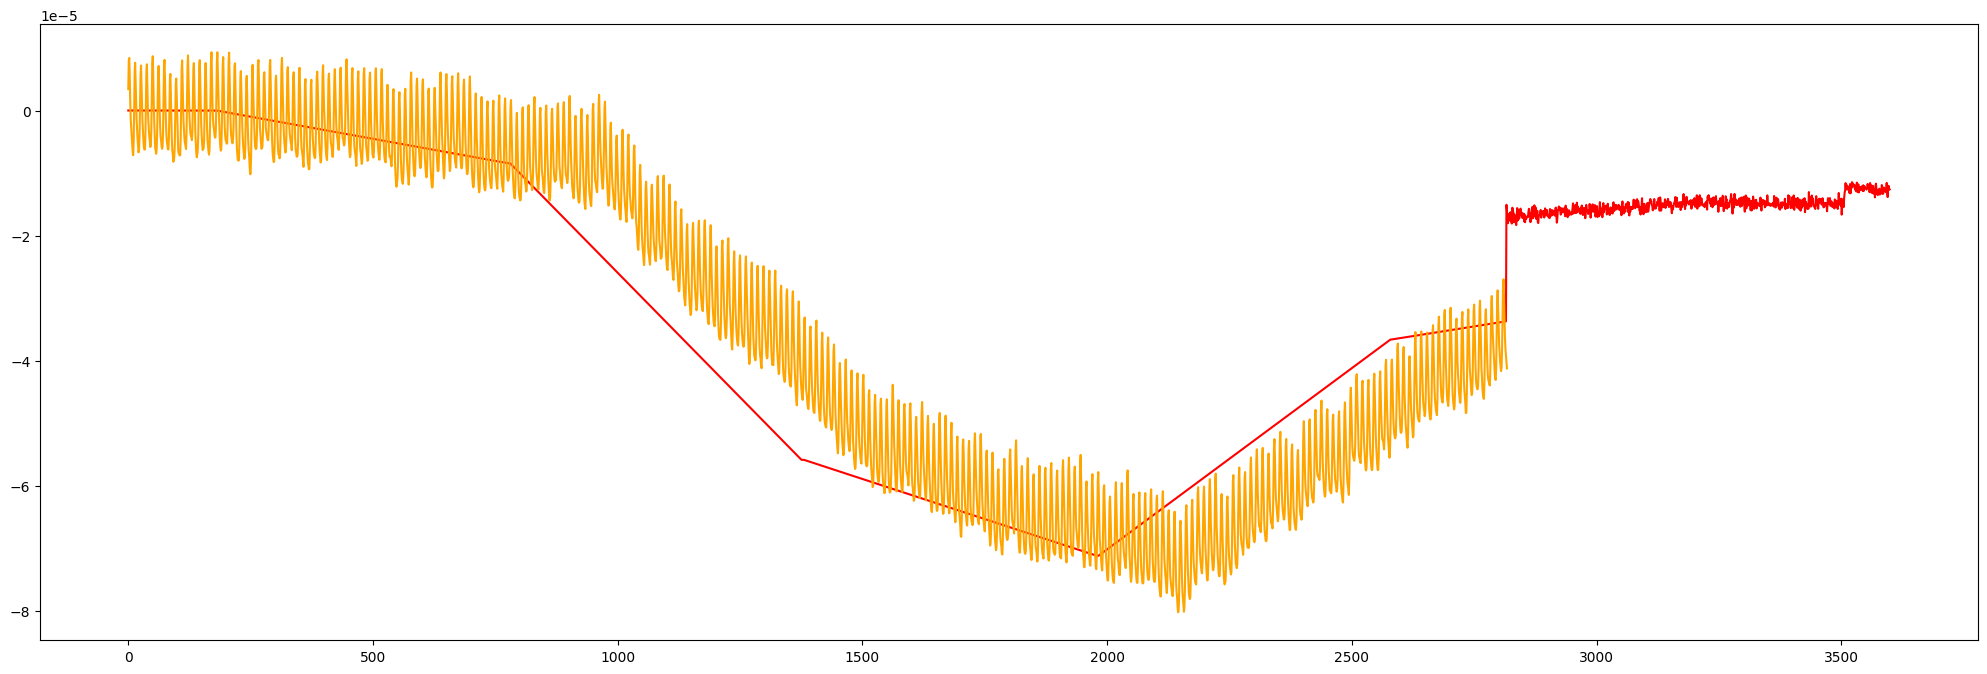

In [34]:
plt.figure(figsize=(25,8))
plt.plot(det585_ts, label='Deterministic Trend SSP585', color='red')
plt.plot(em585_ts, label='Stochastic Ensemble Mean SSP585', color='orange')

# GLOBALSTATS - RESTART CLEANUP

In [37]:
# Check global stats values
det585_globalstats = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/diagnostics/deterministic/DET-SSP585/globalStats.nc")
det126_globalstats = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/diagnostics/deterministic/DET-SSP126/globalStats.nc")
ctrlfbA_globalstats = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/diagnostics/deterministic/ctrlfb_A/globalStats.nc")

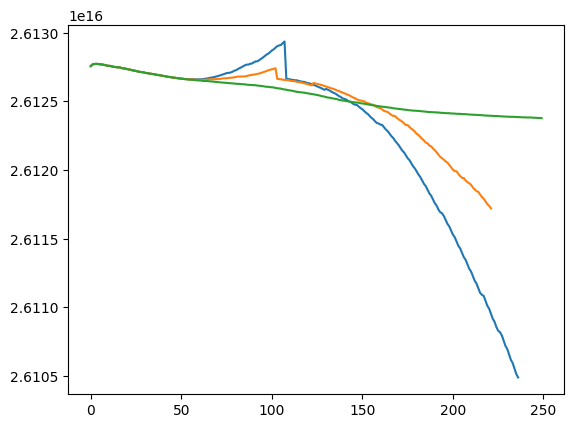

In [39]:
n = 250
plt.plot(det585_globalstats['totalIceVolume'][:n])
plt.plot(det126_globalstats['totalIceVolume'][:n])
plt.plot(ctrlfbA_globalstats['totalIceVolume'][:n])

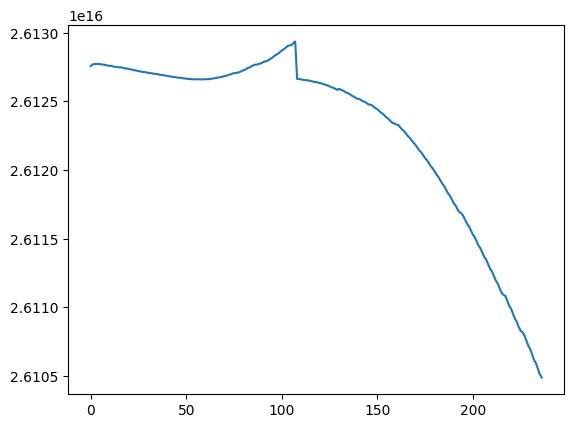

In [ ]:
plt.plot(det585_globalstats['totalIceVolume'][:n])

# create a copy of det585_globalstats with the values between indices 75 to 120 removed




In [ ]:
# Create a copy of det585_globalstats and remove time slices 75 to 120
det585_globalstats_cleaned = det585_globalstats.isel(Time=slice(0, 75)).combine_first(
    det585_globalstats.isel(Time=slice(120, None)).assign_coords(Time=range(det585_globalstats.sizes['Time'] - 45))
)

# Alternative: concatenate the before and after slices
det585_globalstats_cleaned = xr.concat(
    [det585_globalstats.isel(Time=slice(0, 75)), 
     det585_globalstats.isel(Time=slice(120, None))],
    dim='Time'
)

print(f"Original shape: {det585_globalstats.sizes['Time']}")
print(f"Cleaned shape: {det585_globalstats_cleaned.sizes['Time']}")

ValueError: conflicting sizes for dimension 'Time': length 192 on 'Time' and length 117 on {'Time': 'xtime'}

In [50]:
# globalstats is written sequentially.
# some time slices are wrong in that, they were a wrong simulation, and i "restarted the simulation after that. I need to delete these time slices.
# I will delete these time slices from the globalStats.nc files by identifying their timestamps.
# before that, plot these time series with years in the x axis as done earlier by calculating from daysSinceStart.
# I will use the same method as before to calculate the calendar years from daysSinceStart.
# I will then delete the time slices that are incorrect.
# After that, I will plot the time series again to ensure the correct time slices are included


#days585 = f585.variables['daysSinceStart'][:]
#years585 = days585 / 365.0
#years585 = years585 - years585[0]
#cal_years585 = years585 + 2015.0


def calculate_calendar_years(daysSinceStart):
    years = daysSinceStart / 365.0
    years = years - years[0]
    cal_years = years + 2000.0
    return cal_years

# Example usage
cal_years = calculate_calendar_years(det585_globalstats['daysSinceStart'][:].values) # Assuming det585 has 'daysSinceStart' variable
plt.plot(cal_years, det585_globalstats, label='Deterministic Trend SSP585')
plt.plot(cal_years, det126_globalstats, label='Stochastic Ensemble Mean SSP585')


UFuncTypeError: ufunc 'add' cannot use operands with types dtype('<m8[ns]') and dtype('float64')

In [47]:
det585_globalstats['daysSinceStart'].values

array([                  0,   10986592000032000,   21237652999958400,
         31536000000000000,   36916112000016000,   50971586999990400,
         55555952000025600,   63072000000000000,   72803357999971200,
         86669690999990400,   90215358999984000,   94608000000000000,
        106368294000009600,  117653659000012800,  122945664999974400,
        125287608000038399,  126144000000000000,  137347586999971200,
        147919135000003200,  157680000000000000,  169091520000019200,
        180564997999996800,  189216000000000000,  200748159000000000,
        212292409000031999,  220752000000000000,  231426779999961600,
        242948215999987200,  248248926999964800,  252288000000000000,
        263778820000012800,  275257945999958400,  283824000000000000,
        295291019000016000,  306757540000022400,  315360000000000000,
        326833285000003200,  338314917999974399,  346896000000000000,
        358392980999980800,  369900472000003200,  378432000000000000,
        389955358999

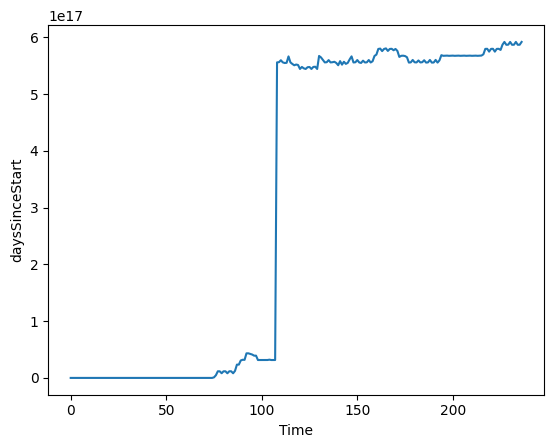

In [55]:
(ctrlfbA_globalstats['daysSinceStart'][:237]-det585_globalstats['daysSinceStart'][:237]).plot()